# Stochastic model using Kolmogorov equations

using pasture size A=100

In [2]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

In [3]:
R = 0.00888
K = 0.00772
A = 100

In [4]:
#initial state 25 grass blocks
p0 = np.zeros(A+1)
p0[5]=1

In [5]:
#r matrix

def growthRate(Ng, N):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N):
    return N*R*Ng/A

def rij(i, j, N):
    """value of element r_ij in the r matrix"""

    if i == 0:
        return 0
    elif j == i+1:
        return growthRate(i, N)
    elif i == j+1:
        return eatRate(i, N)
    elif i == j:
        return -growthRate(i, N) - eatRate(i, N)
    else:
        return 0

def rMatrix(N):
    r_matrix = np.zeros((A+1,A+1))
    for i in range(0, A+1):
        for j in range(0, A+1):
            r_matrix[i,j] = rij(i, j, N)
    return r_matrix

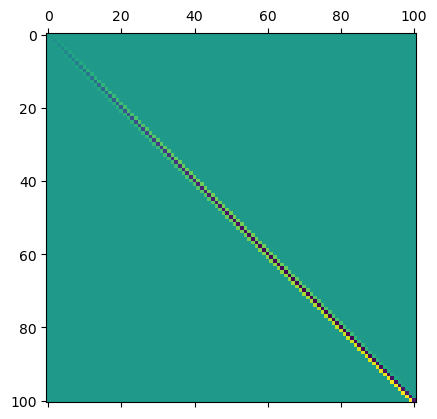

In [6]:
f, ax = plt.subplots()

ax.matshow(rMatrix(int(A*0.4)))

plt.show()

In [7]:
def simulate(N, time, init):
    """return solution to kolmogorov equations given value for N, how long to simulate, and initial condition
    if init is "max", Ng(0) = A
    if init is "eq", Ng(0) is the equilibrium value from the deterministic model
    """
    #R matrix for give value of N
    r_matrix = rMatrix(N)

    #initial value
    p0 = np.zeros(A+1)
    if init == "max":
        p0[A]=1
    elif init == "eq":
        p0[int(A-N*R/K)]=1
    else:
        raise ValueError("init must be \"max\" or \"eq\"")

    #RHS of the system
    def sys(t, y):
        return np.matmul(y, r_matrix)
    s = sp.integrate.solve_ivp(sys, (0, time), p0)
    print("finished solution N={0}, Ng0 {1}".format(N, init))
    return s

In [8]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [9]:
sol_max = {str(i): simulate(i, 3600, "max") for i in range(5, 90, 5)}

sol_eq = {str(i): simulate(i, 3600, "eq") for i in range(5, 90, 5)}

finished solution N=5, Ng0 max
finished solution N=10, Ng0 max
finished solution N=15, Ng0 max
finished solution N=20, Ng0 max
finished solution N=25, Ng0 max
finished solution N=30, Ng0 max
finished solution N=35, Ng0 max
finished solution N=40, Ng0 max
finished solution N=45, Ng0 max
finished solution N=50, Ng0 max
finished solution N=55, Ng0 max
finished solution N=60, Ng0 max
finished solution N=65, Ng0 max
finished solution N=70, Ng0 max
finished solution N=75, Ng0 max
finished solution N=80, Ng0 max
finished solution N=85, Ng0 max
finished solution N=5, Ng0 eq
finished solution N=10, Ng0 eq
finished solution N=15, Ng0 eq
finished solution N=20, Ng0 eq
finished solution N=25, Ng0 eq
finished solution N=30, Ng0 eq
finished solution N=35, Ng0 eq
finished solution N=40, Ng0 eq
finished solution N=45, Ng0 eq
finished solution N=50, Ng0 eq
finished solution N=55, Ng0 eq
finished solution N=60, Ng0 eq
finished solution N=65, Ng0 eq
finished solution N=70, Ng0 eq
finished solution N=75, 

In [33]:
sol_max["30"]["y"].shape

(101, 762)

In [37]:
def pmfE(p):
    """calculate the expected value of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""

    return np.sum(p * np.arange(0, p.size))

def pmfVar(p):
    """calculate the variance of the pmf p
    p should be a vector where p[i] represents the probability of state x=i"""
    return np.sum(p*(np.arange(0, p.size)-pmfE(p))**2)

In [38]:
def evolutionPlot(a, sol, times):
    """on the axes a, plot the distribution of sol at times t
    """

    for i in times:
        a.plot(sol["y"][:,timeToIndex(sol["t"],i)],
            label="t={0:.2f}".format(sol["t"][timeToIndex(sol["t"],i)]))

In [57]:
def expPlot(a, sol):
    """plot expected value of sol as a function of time"""

    expval = np.array([
        pmfE(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    a.plot(sol["t"], expval)

def varPlot(a, sol):
    """plot the variance of sol as a function of time"""

    vars = np.array([
        pmfVar(sol["y"][:,j]) for j in range(0, sol["y"].shape[1])
    ])

    a.plot(sol["t"], vars)

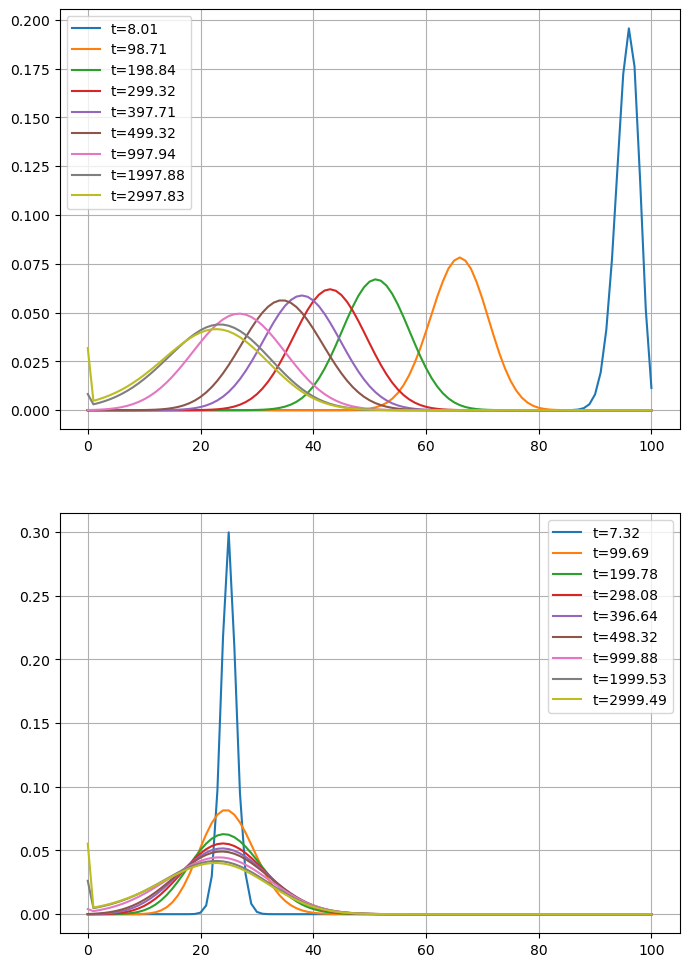

In [58]:
f, (ax, ax2) = plt.subplots(nrows=2, figsize=(8, 12))

evolutionPlot(ax, sol_max["65"], [10, 100, 200, 300, 400, 500, 1000, 2000, 3000])

evolutionPlot(ax2, sol_eq["65"], [10, 100, 200, 300, 400, 500, 1000, 2000, 3000])

ax.legend()
ax2.legend()

ax.grid(True)
ax2.grid(True)

plt.show()

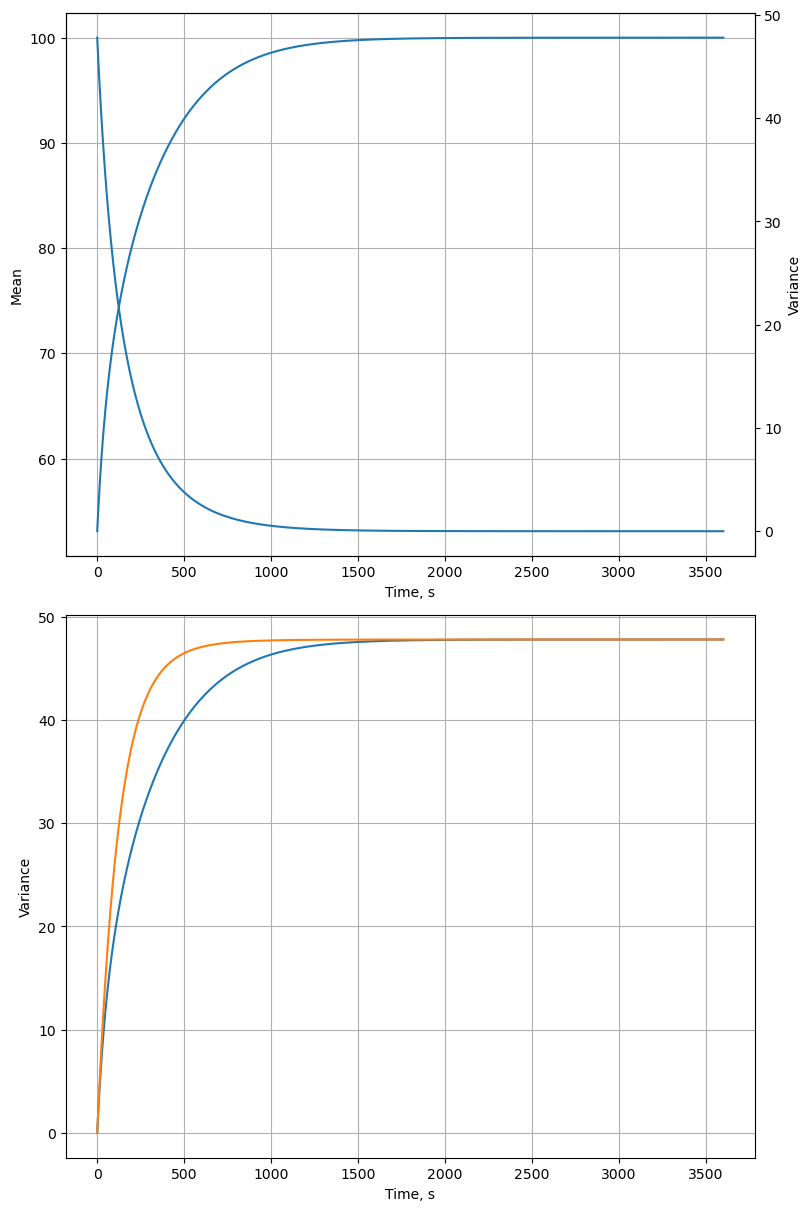

In [66]:
f, (ax1, ax3) = plt.subplots(nrows=2, figsize=(8, 12), layout="constrained")

ax2 = ax1.twinx()

expPlot(ax1, sol_max["40"])
varPlot(ax2, sol_max["40"])

varPlot(ax3, sol_max["40"])
varPlot(ax3, sol_eq["40"])

ax1.grid(True)
ax1.set_xlabel("Time, s")
ax1.set_ylabel("Mean")
ax2.set_ylabel("Variance")

ax3.grid(True)
ax3.set_xlabel("Time, s")
ax3.set_ylabel("Variance")

plt.show()